# Time Series Analysis, Outlier Detection and Forecasting using Holt-Winters

## Objective

This project demonstrates a complete workflow for a time series analysis:

- Generate a synthetic monthly dataset
- Explore the data
- Perform STL decomposition
- Detect outliers using residuals
- Clean the data
- Build a Holt-Winters forecasting model
- Evaluate forecasting performance
- Produce a 24‑month forecast


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.random.seed(42)


## 2. Generate Synthetic Dataset

In [2]:
dates = pd.date_range('2015-01-01', periods=120, freq='MS')

trend = np.linspace(100,250,120)
seasonality = 20*np.sin(2*np.pi*np.arange(120)/12)
noise = np.random.normal(0,6,120)

sales = trend + seasonality + noise

outlier_idx=[20,45,70,90,110]
sales[outlier_idx]+=np.array([40,-45,55,-50,60])

df=pd.DataFrame({'Sales':sales},index=dates)
df.head()


,Sales
2015-01-01,102.980285
2015-02-01,110.430918
2015-03-01,123.727648
2015-04-01,132.919692
2015-05-01,120.957605


## 3. Exploratory Data Analysis

In [3]:
df.describe()

,Sales
count,120.000000
mean,175.024986
std,47.087806
min,87.403624
25%,135.201600
50%,175.953821
75%,213.763911
max,304.463343


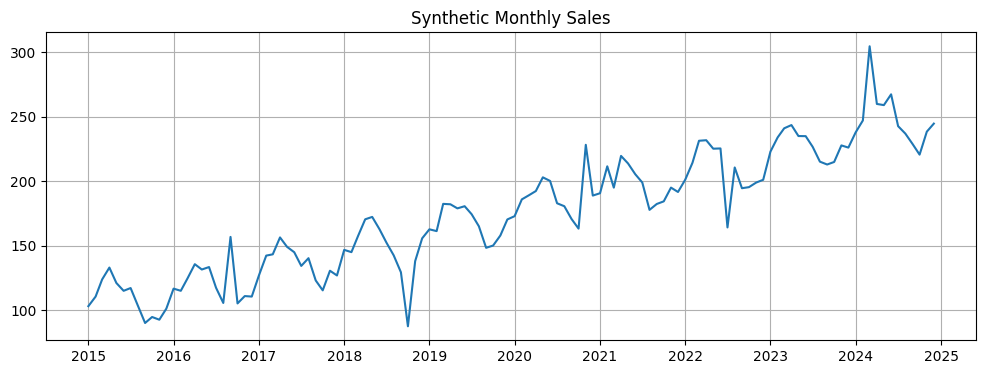

In [4]:
plt.figure(figsize=(12,4))
plt.plot(df.index,df.Sales)
plt.title("Synthetic Monthly Sales")
plt.grid(True)
plt.show()

The dataset contains a linear upward trend, yearly seasonality, random noise and several injected anomalies.

## 4. STL Decomposition

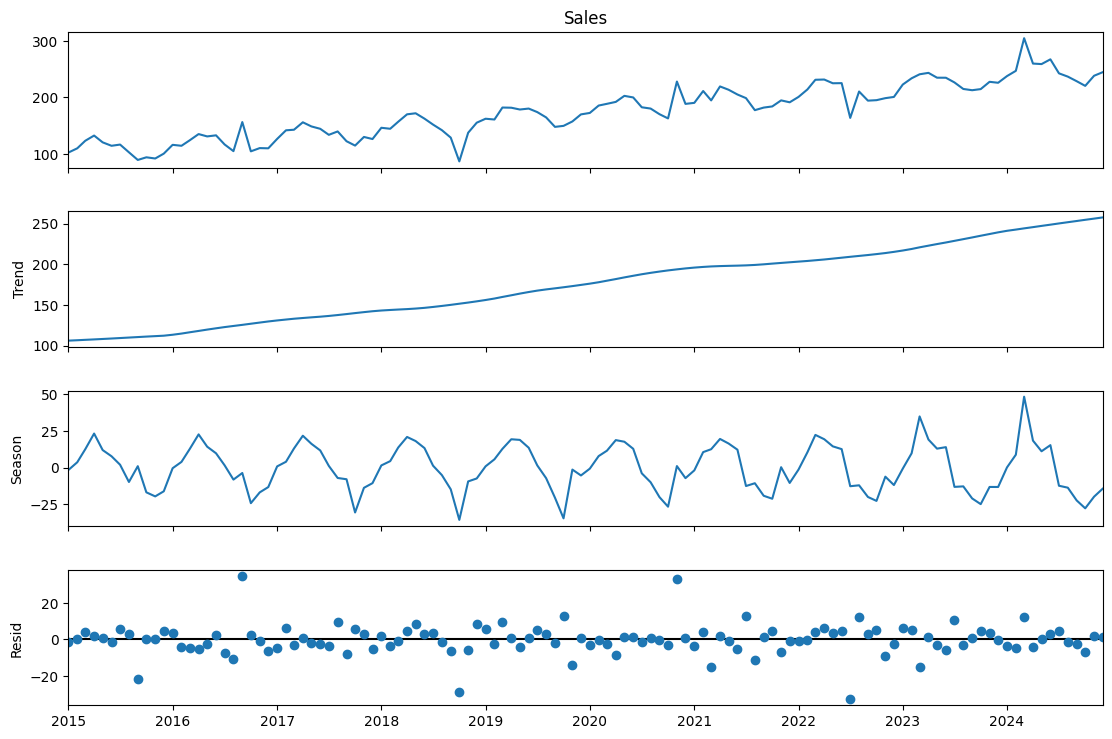

In [5]:
stl=STL(df['Sales'],period=12)
result=stl.fit()
fig=result.plot()
fig.set_size_inches(12,8)
plt.show()

Residuals are used for anomaly detection because trend and seasonality have already been removed.

## 5. Detect Outliers

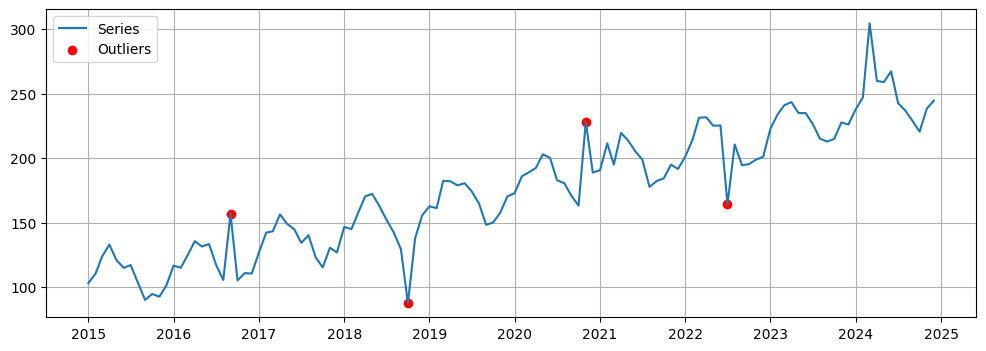

                 Sales
2016-09-01  156.683469
2018-10-01   87.403624
2020-11-01  228.083160
2022-07-01  164.027843


In [6]:
res=result.resid
z=np.abs(zscore(res))
outliers=z>3

plt.figure(figsize=(12,4))
plt.plot(df.index,df.Sales,label='Series')
plt.scatter(df.index[outliers],df.Sales[outliers],color='red',label='Outliers')
plt.legend()
plt.grid(True)
plt.show()

print(df[outliers])


## 6. Clean Dataset

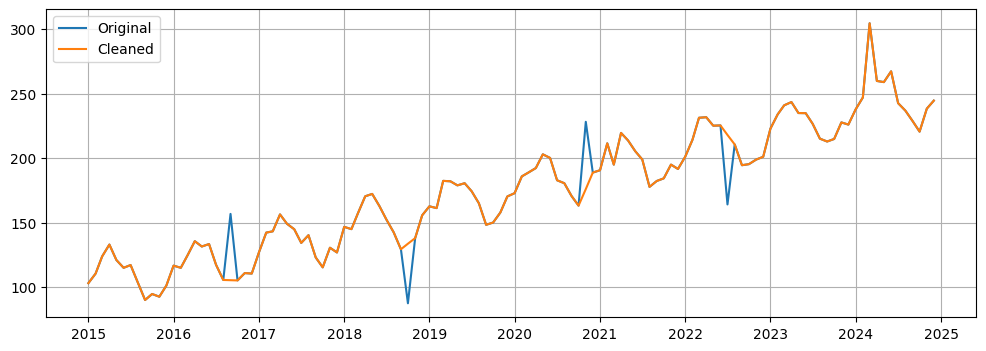

In [7]:
clean=df.copy()
clean.loc[outliers,'Sales']=np.nan
clean['Sales']=clean['Sales'].interpolate()

plt.figure(figsize=(12,4))
plt.plot(df.index,df.Sales,label='Original')
plt.plot(clean.index,clean.Sales,label='Cleaned')
plt.legend()
plt.grid(True)
plt.show()


## 7. Train/Test Split

In [8]:
train=clean.iloc[:-12]
test=clean.iloc[-12:]


## 8. Holt-Winters Forecast

In [9]:
model=ExponentialSmoothing(train['Sales'],
                                 trend='add',
                                 seasonal='add',
                                 seasonal_periods=12).fit()

forecast=model.forecast(12)

mae=mean_absolute_error(test['Sales'],forecast)
rmse=np.sqrt(mean_squared_error(test['Sales'],forecast))
mape=np.mean(np.abs((test['Sales']-forecast)/test['Sales']))*100

print(f'MAE : {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')


MAE : 7.54
RMSE: 15.69
MAPE: 2.73%


## 9. Forecast Visualization

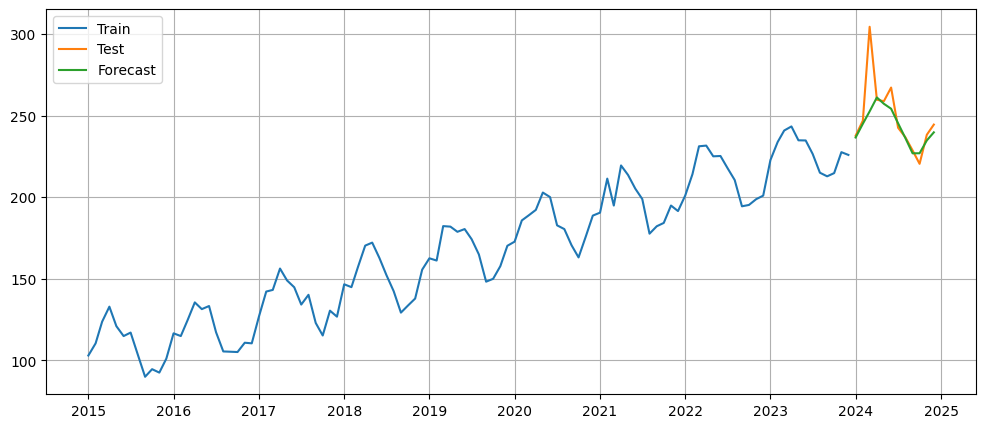

In [10]:
plt.figure(figsize=(12,5))
plt.plot(train.index,train.Sales,label='Train')
plt.plot(test.index,test.Sales,label='Test')
plt.plot(forecast.index,forecast,label='Forecast')
plt.legend()
plt.grid(True)
plt.show()


## 10. Forecast Next 24 Months

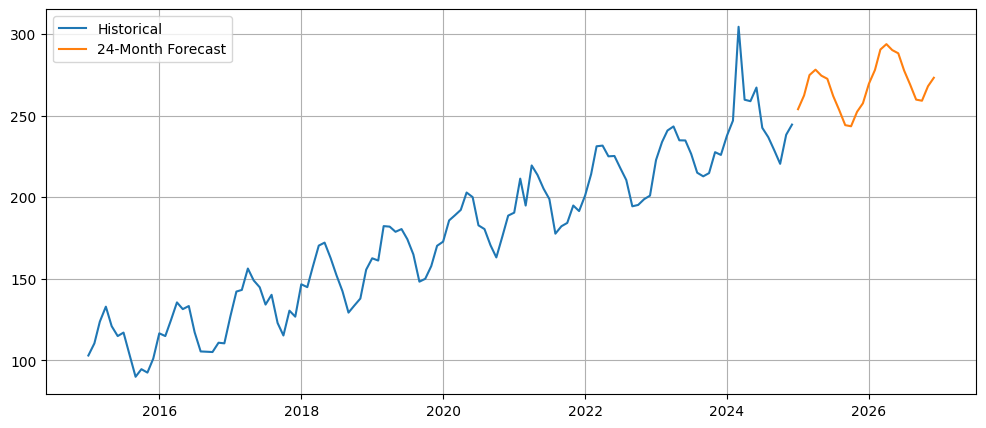

In [11]:
final_model=ExponentialSmoothing(clean['Sales'],
                                       trend='add',
                                       seasonal='add',
                                       seasonal_periods=12).fit()

future=final_model.forecast(24)

plt.figure(figsize=(12,5))
plt.plot(clean.index,clean.Sales,label='Historical')
plt.plot(future.index,future,label='24-Month Forecast')
plt.legend()
plt.grid(True)
plt.show()


# Conclusions

- STL successfully separated trend, seasonality and residual components.
- Outliers were detected using standardized residuals.
- Cleaning anomalies improves the quality of forecasting.
- Holt-Winters is appropriate for time series exhibiting both trend and seasonality.

## Possible Extensions

- SARIMA
- Prophet
- XGBoost
- Isolation Forest for anomaly detection
- Cross-validation for time series
